In [2]:
!pip install scikit-learn pandas numpy tensorflow

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.3 MB 13.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.9 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- -----------------------

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 1. Read the data files you uploaded
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. Extract labels (the digits) and features (the pixel columns)
y = train_df['label'].values
X = train_df.drop(columns=['label']).values

# 3. Reshape flat rows back into 28x28 grayscale image structures
X = X.reshape(-1, 28, 28, 1)
X_test = test_df.values.reshape(-1, 28, 28, 1)

# 4. Scale pixel values from [0-255] down to [0.0-1.0]
X = X / 255.0
X_test = X_test / 255.0

# 5. Hold back 10% of the training data to validate accuracy later
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

print("✅ Data successfully loaded and processed!")
print(f"Training images shape: {X_train.shape}")
print(f"Validation images shape: {X_val.shape}")

✅ Data successfully loaded and processed!
Training images shape: (37800, 28, 28, 1)
Validation images shape: (4200, 28, 28, 1)


In [4]:
model = models.Sequential([
    # Layer 1: Scan for simple edges and lines
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Combine those edges into more complex features (like loops or arcs)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: Flatten the image data into a single line array and pass it to standard layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    # Helps prevent the network from memorizing the specific samples
    layers.Dropout(0.3),
    # 10 output slots representing digits 0 to 9
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🧠 Model architecture constructed and ready!")

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🧠 Model architecture constructed and ready!


In [5]:
# This starts the learning process
history = model.fit(
    X_train,
    y_train,
    epochs=10,        # It will look through the entire dataset 10 times
    batch_size=64,     # It will look at 64 images at a time before updating weights
    validation_data=(X_val, y_val)
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9184 - loss: 0.2624 - val_accuracy: 0.9748 - val_loss: 0.0747
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9753 - loss: 0.0825 - val_accuracy: 0.9829 - val_loss: 0.0528
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9816 - loss: 0.0595 - val_accuracy: 0.9845 - val_loss: 0.0476
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9854 - loss: 0.0469 - val_accuracy: 0.9871 - val_loss: 0.0410
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9877 - loss: 0.0390 - val_accuracy: 0.9886 - val_loss: 0.0336
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9900 - val_loss: 0.0349
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.9895 - val_loss: 0.0345
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9919 - loss: 0.0238 - val_a

In [6]:
# Save the model architecture and trained weights
model.save('digits_model.h5')
print("💾 'digits_model.h5' has been successfully saved to your folder!")

💾 'digits_model.h5' has been successfully saved to your folder!


In [7]:
# 1. Use the model to predict probability arrays for the test images
predictions = model.predict(X_test)

# 2. Extract the index with the highest probability score for each image
predicted_classes = np.argmax(predictions, axis=1)

# 3. Format the array into the structure expected by Kaggle
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(predicted_classes) + 1),
    'Label': predicted_classes
})

# 4. Save the table to a CSV file on your machine
submission.to_csv('submission.csv', index=False)
print("🎯 Finished! 'submission.csv' has been generated and saved in your project folder.")

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
🎯 Finished! 'submission.csv' has been generated and saved in your project folder.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


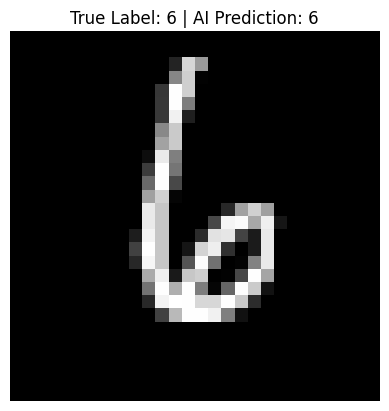

In [9]:
import matplotlib.pyplot as plt

# 1. Pick a random image from your validation pool
test_index = 35  # You can change this number to look at different images
sample_image = X_val[test_index]
true_label = y_val[test_index]

# 2. Reshape the image so the model can read it as a single sample batch
input_sample = sample_image.reshape(1, 28, 28, 1)

# 3. Run a prediction
pred_probabilities = model.predict(input_sample)
predicted_label = np.argmax(pred_probabilities)

# 4. Display the image and the model's guess side-by-side
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"True Label: {true_label} | AI Prediction: {predicted_label}")
plt.axis('off')
plt.show()

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
📈 1. Overall Accuracy: 99.17%
📉 2. Cross-Entropy Log Loss: 0.0312

📊 3. Detailed Class-wise Metrics (Precision, Recall, F1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       408
           1       1.00      1.00      1.00       471
           2       0.99      1.00      0.99       420
           3       0.99      0.99      0.99       506
           4       0.99      0.98      0.99       397
           5       0.99      0.98      0.99       339
           6       0.99      1.00      0.99       402
           7       1.00      0.98      0.99       438
           8       0.99      0.99      0.99       403
           9       0.98      1.00      0.99       416

    accuracy                           0.99      4200
   macro avg       0.99      0.99      0.99      4200
weighted avg       0.99      0.99      0.99      4200


🎨 4. Generating Confusion Matrix Visual...


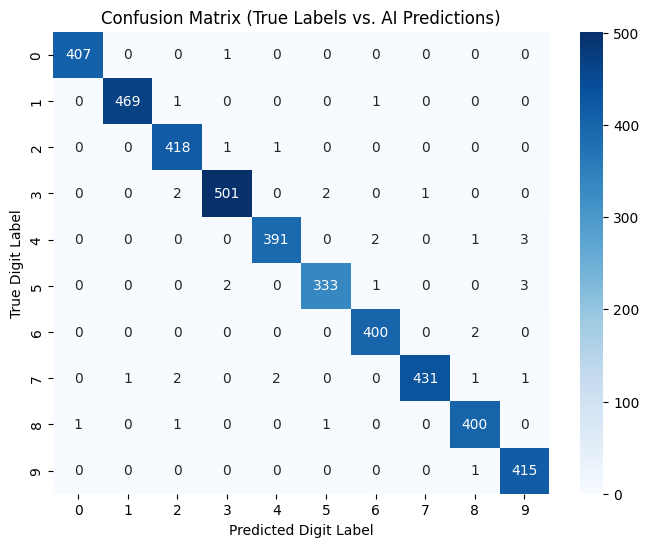

In [10]:
from sklearn.metrics import classification_report, accuracy_score, log_loss, confusion_matrix
import seaborn as sns

# 1. Get predictions over the validation pool
val_predictions = model.predict(X_val)
val_predicted_classes = np.argmax(val_predictions, axis=1)

# --- METRIC 1: Overall Accuracy ---
acc = accuracy_score(y_val, val_predicted_classes)

# --- METRIC 2: Log Loss (Cross-Entropy Loss) ---
loss = log_loss(y_val, val_predictions)

print("=========================================")
print(f"📈 1. Overall Accuracy: {acc * 100:.2f}%")
print(f"📉 2. Cross-Entropy Log Loss: {loss:.4f}")
print("=========================================\n")

# --- METRIC 3: Precision, Recall, & F1-Score Report ---
print("📊 3. Detailed Class-wise Metrics (Precision, Recall, F1):")
print(classification_report(y_val, val_predicted_classes))
print("=========================================\n")

# --- METRIC 4: Confusion Matrix Plot ---
print("🎨 4. Generating Confusion Matrix Visual...")
cm = confusion_matrix(y_val, val_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.title('Confusion Matrix (True Labels vs. AI Predictions)')
plt.ylabel('True Digit Label')
plt.xlabel('Predicted Digit Label')
plt.show()